# MEI Generation for 3D Video Model

Generate Most Exciting Inputs (MEIs) for a trained `VideoFiringRateEncoder` with `Factorized3dCore`.

Two MEI types:
1. **Video MEI** — optimize a full spatio-temporal video clip `(1, 1, T, 36, 64)`, revealing both spatial and temporal receptive field structure
2. **Static MEI** — optimize a single frame `(1, 1, 36, 64)` repeated across time, showing spatial RF only

The `mei` library's `ConstrainedOutputModel` cannot be used directly because it indexes dimension 1
of the output, which is the **time** dimension for video models (not neurons). Custom wrapper
callables handle this correctly.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import types
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import HTML

# Mock datajoint and gitpython (only needed by nnfabrik's dj_helpers, not used here)
_dj = types.ModuleType('datajoint')
_dj.config = {}
for sub in ['utils', 'schema', 'schemas', 'fetch']:
    mod = types.ModuleType(f'datajoint.{sub}')
    setattr(_dj, sub, mod)
    sys.modules[f'datajoint.{sub}'] = mod
_dj.utils.to_camel_case = lambda s: s
_dj.schema.Schema = type('Schema', (), {})
_dj.schemas.Schema = type('Schema', (), {})
_dj.fetch.DataJointError = Exception
sys.modules['datajoint'] = _dj

_git = types.ModuleType('git')
_git.Repo = type('Repo', (), {})
_git.cmd = types.ModuleType('git.cmd')
sys.modules['git'] = _git
sys.modules['git.cmd'] = _git.cmd

# Add package paths
# NOTE: Do NOT add BASE/sensorium — its sensorium/ has __init__.py (regular package)
# which shadows the latent_space_model/sensorium/ namespace package.
# latent_space_model/sensorium/ has make_model, video_encoder, readouts — everything we need.
BASE = '/mnt/vast-nhr/projects/nix00014/goirik/MOZAIK-new'
sys.path.insert(0, f'{BASE}/sensorium/notebooks/model_tutorial/nnfabrik_base')
sys.path.insert(0, f'{BASE}/experanto')
sys.path.insert(0, f'{BASE}/mei')
sys.path.insert(0, f'{BASE}/neuralpredictors')
sys.path.insert(0, f'{BASE}/latent_space_model')

from sensorium.models.make_model import make_video_model
from mei.optimization import MEI, optimize
from mei.stoppers import NumIterations
from mei.objectives import EvaluationObjective
from mei.tracking import Tracker
from mei.initial import RandomNormal
from mei.postprocessing import PNormConstraintAndClip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Regularization callables

Defined early so they're available for both the simulated validation and the real model.

- **2D versions**: for static MEI / simulated neurons `(B, C, H, W)`
- **Video versions**: for video MEI `(B, C, T, H, W)` — apply 2D ops per frame

In [2]:
# --- 2D versions (for static MEI, input shape (B, C, H, W)) ---

class FourierPrecondition:
    """Lowpass-filter gradient in Fourier space: G(fx,fy) = (fx^2+fy^2)^(-alpha)."""
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self._filter_cache = {}

    def _get_filter(self, H, W, device):
        key = (H, W, device)
        if key not in self._filter_cache:
            fy = torch.fft.fftfreq(H, device=device).unsqueeze(1)
            fx = torch.fft.fftfreq(W, device=device).unsqueeze(0)
            freq_sq = fx ** 2 + fy ** 2
            freq_sq[0, 0] = 1.0
            filt = freq_sq ** (-self.alpha)
            filt[0, 0] = 1.0
            self._filter_cache[key] = filt
        return self._filter_cache[key]

    def __call__(self, grad, i_iteration):
        H, W = grad.shape[-2:]
        filt = self._get_filter(H, W, grad.device)
        return torch.fft.ifft2(torch.fft.fft2(grad) * filt).real


def _make_gaussian_kernel_2d(sigma, dtype, device):
    """Build a 2D Gaussian kernel with size adapted to sigma (radius = ceil(3*sigma))."""
    radius = int(np.ceil(3.0 * sigma))
    kernel_size = 2 * radius + 1
    x = torch.arange(kernel_size, dtype=dtype, device=device) - radius
    kernel_1d = torch.exp(-0.5 * (x / max(sigma, 1e-6)) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = (kernel_1d[:, None] * kernel_1d[None, :]).unsqueeze(0).unsqueeze(0)
    return kernel_2d, radius


class DecayingGaussianBlur:
    """Gaussian blur with sigma decaying linearly over iterations.
    
    Kernel size adapts to sigma each iteration (radius = ceil(3*sigma)).
    If preserve_norm=True, rescales after blur to maintain L2 norm (needed
    for models with weak gradients like 3D video models).
    """
    def __init__(self, sigma_start=3.0, sigma_end=0.5, n_iter=500, preserve_norm=False):
        self.sigma_start = sigma_start
        self.sigma_end = sigma_end
        self.n_iter = n_iter
        self.preserve_norm = preserve_norm

    def __call__(self, mei, i_iteration):
        sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * (i_iteration / max(self.n_iter - 1, 1))
        kernel_2d, padding = _make_gaussian_kernel_2d(sigma, mei.dtype, mei.device)
        if self.preserve_norm:
            norm_before = mei.norm()
        blurred = F.conv2d(mei, kernel_2d, padding=padding)
        if self.preserve_norm:
            norm_after = blurred.norm()
            if norm_after > 0:
                blurred = blurred * (norm_before / norm_after)
        return blurred


class RandomJitter:
    """Random spatial jitter for 2D input (B, C, H, W)."""
    def __init__(self, amount=2):
        self.amount = amount

    def __call__(self, mei, i_iteration):
        ox = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        oy = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        return torch.roll(mei, shifts=(ox, oy), dims=(2, 3))


# --- Video versions (for video MEI, input shape (B, C, T, H, W)) ---

class FourierPreconditionVideo:
    """Lowpass-filter gradient per frame in Fourier space."""
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self._filter_cache = {}

    def _get_filter(self, H, W, device):
        key = (H, W, device)
        if key not in self._filter_cache:
            fy = torch.fft.fftfreq(H, device=device).unsqueeze(1)
            fx = torch.fft.fftfreq(W, device=device).unsqueeze(0)
            freq_sq = fx ** 2 + fy ** 2
            freq_sq[0, 0] = 1.0
            filt = freq_sq ** (-self.alpha)
            filt[0, 0] = 1.0
            self._filter_cache[key] = filt
        return self._filter_cache[key]

    def __call__(self, grad, i_iteration):
        H, W = grad.shape[-2:]
        filt = self._get_filter(H, W, grad.device)
        return torch.fft.ifft2(torch.fft.fft2(grad) * filt).real


class DecayingGaussianBlurVideo:
    """Gaussian blur per frame for video tensor (B, C, T, H, W).
    
    Kernel size adapts to sigma. If preserve_norm=True, rescales to maintain L2 norm.
    """
    def __init__(self, sigma_start=3.0, sigma_end=0.5, n_iter=500, preserve_norm=False):
        self.sigma_start = sigma_start
        self.sigma_end = sigma_end
        self.n_iter = n_iter
        self.preserve_norm = preserve_norm

    def __call__(self, mei, i_iteration):
        sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * (i_iteration / max(self.n_iter - 1, 1))
        kernel_2d, padding = _make_gaussian_kernel_2d(sigma, mei.dtype, mei.device)
        B, C, T, H, W = mei.shape
        mei_flat = mei.reshape(B * C * T, 1, H, W)
        if self.preserve_norm:
            norm_before = mei_flat.norm()
        blurred = F.conv2d(mei_flat, kernel_2d, padding=padding)
        if self.preserve_norm:
            norm_after = blurred.norm()
            if norm_after > 0:
                blurred = blurred * (norm_before / norm_after)
        return blurred.reshape(B, C, T, H, W)


class RandomJitterVideo:
    """Random spatial jitter for video (B, C, T, H, W). Rolls spatial dims 3, 4."""
    def __init__(self, amount=2):
        self.amount = amount

    def __call__(self, mei, i_iteration):
        ox = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        oy = torch.randint(-self.amount, self.amount + 1, (1,)).item()
        return torch.roll(mei, shifts=(ox, oy), dims=(3, 4))


class LuminanceNormalization:
    """Normalize to target mean luminance and RMS contrast (0-255 scale)."""
    def __init__(self, target_mean=111.0, target_rms=16.0):
        self.target_mean = target_mean
        self.target_rms = target_rms

    def __call__(self, mei, i_iteration=0):
        img = mei - mei.mean()
        rms = img.pow(2).mean().sqrt()
        if rms > 0:
            img = img * (self.target_rms / rms)
        return img + self.target_mean

## Pipeline validation with simulated complex cell

Before running MEI on the trained video model, verify the optimization pipeline
recovers the known preferred stimulus of a simulated complex cell (quadrature Gabor pair).
The ground truth is known — the MEI should look like a Gabor filter.

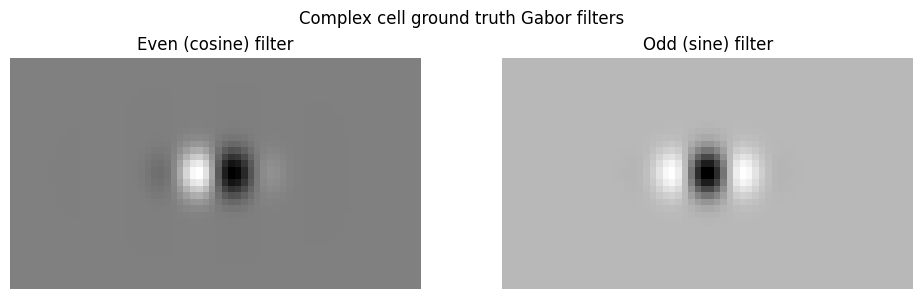

Complex cell output shape: torch.Size([1]), value: 0.4666


In [3]:
from laminr.simulated_models import complex_neuron_generator

# Create a complex cell at the center of the image, using same spatial res as video model
# img_res is [W, H] for meshgrid convention — np.meshgrid(linspace(W), linspace(H)) -> (H, W)
img_res = [64, 36]
loc = [0.0, 0.0]
complex_cell, grid = complex_neuron_generator(loc, img_res)
complex_cell = complex_cell.to(device).eval()

# Show the ground truth filters
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('Even (cosine) filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('Odd (sine) filter')
for ax in axes:
    ax.axis('off')
plt.suptitle('Complex cell ground truth Gabor filters', fontsize=12)
plt.tight_layout()
plt.show()

# Verify forward pass works
with torch.no_grad():
    test = torch.randn(1, 1, 36, 64).to(device)
    out = complex_cell(test)
    print(f"Complex cell output shape: {out.shape}, value: {out.item():.4f}")

Vanilla MEI final activation: 2.8600


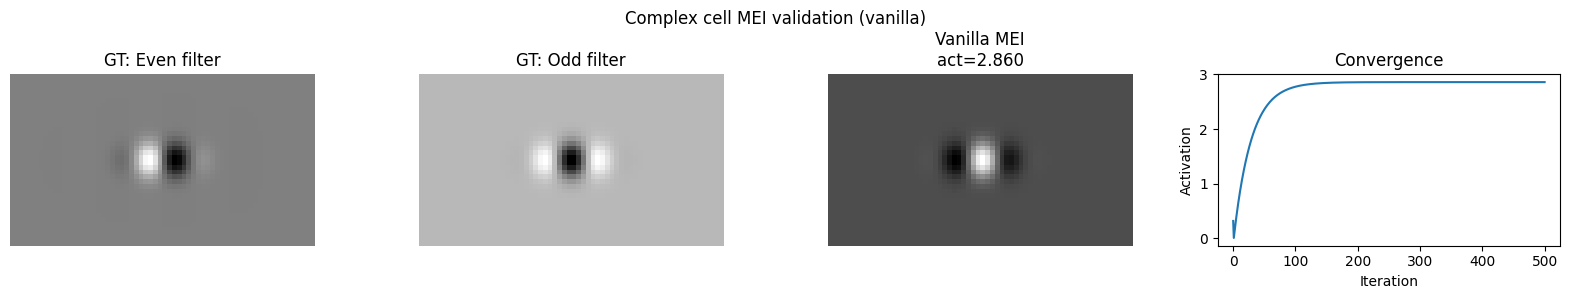

In [4]:
# Run MEI optimization on the complex cell — vanilla recipe
torch.manual_seed(42)

initial = RandomNormal()(1, 1, 36, 64).to(device)
optimizer = torch.optim.SGD([initial], lr=0.1)

mei_obj = MEI(
    func=complex_cell,
    initial=initial,
    optimizer=optimizer,
    transparency=False,
    inhibitory=False,
    postprocessing=PNormConstraintAndClip(
        norm_value=30.0, p=1,
        max_pixel_value=1.0, min_pixel_value=-1.0,
    ),
)

stopper = NumIterations(num_iterations=500)
tracker = Tracker(evaluation=EvaluationObjective(interval=1))
final_eval, mei_result = optimize(mei_obj, stopper, tracker)
cc_activations_vanilla = tracker.log['evaluation']['values']

print(f"Vanilla MEI final activation: {final_eval:.4f}")

# Visualize: ground truth vs MEI
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('GT: Even filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('GT: Odd filter')
axes[2].imshow(mei_result.squeeze().detach().cpu().numpy(), cmap='gray')
axes[2].set_title(f'Vanilla MEI\nact={final_eval:.3f}')
axes[3].plot(cc_activations_vanilla)
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel('Activation')
axes[3].set_title('Convergence')
for ax in axes[:3]:
    ax.axis('off')
plt.suptitle('Complex cell MEI validation (vanilla)', fontsize=12)
plt.tight_layout()
plt.show()

Paper MEI final activation: 1.0542


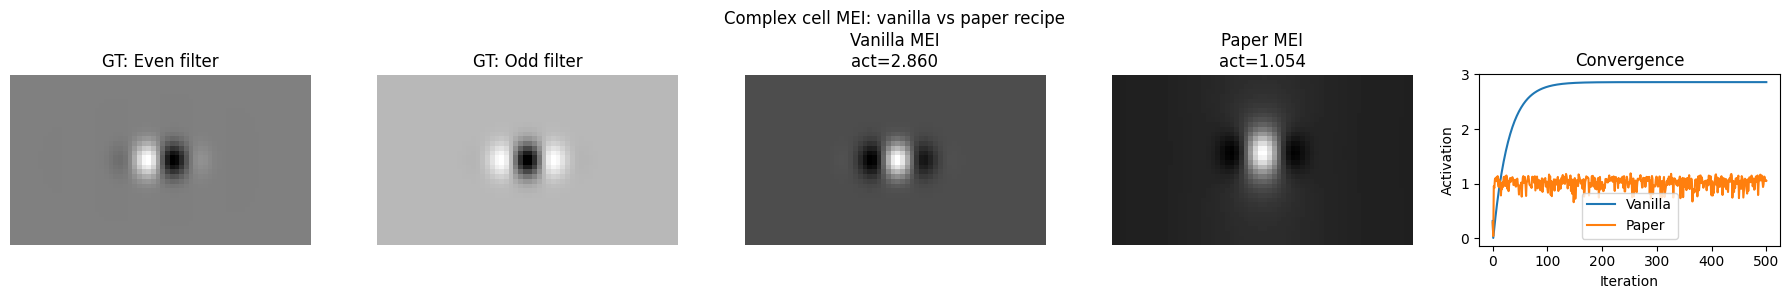

Pipeline validated — same recipe used for both complex cell and real model.


In [5]:
# Run MEI optimization on the complex cell — paper recipe
# (Fourier precondition + jitter + PNormConstraintAndClip, no blur)
torch.manual_seed(42)

initial_paper = RandomNormal()(1, 1, 36, 64).to(device)
optimizer_paper = torch.optim.SGD([initial_paper], lr=0.1)

mei_paper = MEI(
    func=complex_cell,
    initial=initial_paper,
    optimizer=optimizer_paper,
    transparency=False,
    inhibitory=False,
    transform=RandomJitter(amount=2),
    precondition=FourierPrecondition(alpha=0.6),
    postprocessing=PNormConstraintAndClip(
        norm_value=30.0, p=1,
        max_pixel_value=1.0, min_pixel_value=-1.0,
    ),
)

stopper_paper = NumIterations(num_iterations=500)
tracker_paper = Tracker(evaluation=EvaluationObjective(interval=1))
final_eval_paper, mei_result_paper = optimize(mei_paper, stopper_paper, tracker_paper)
cc_activations_paper = tracker_paper.log['evaluation']['values']

print(f"Paper MEI final activation: {final_eval_paper:.4f}")

# Side-by-side: vanilla vs paper
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(complex_cell.even_filter.cpu().numpy(), cmap='gray')
axes[0].set_title('GT: Even filter')
axes[1].imshow(complex_cell.odd_filter.cpu().numpy(), cmap='gray')
axes[1].set_title('GT: Odd filter')
axes[2].imshow(mei_result.squeeze().detach().cpu().numpy(), cmap='gray')
axes[2].set_title(f'Vanilla MEI\nact={cc_activations_vanilla[-1]:.3f}')
axes[3].imshow(mei_result_paper.squeeze().detach().cpu().numpy(), cmap='gray')
axes[3].set_title(f'Paper MEI\nact={cc_activations_paper[-1]:.3f}')
axes[4].plot(cc_activations_vanilla, label='Vanilla')
axes[4].plot(cc_activations_paper, label='Paper')
axes[4].legend()
axes[4].set_xlabel('Iteration')
axes[4].set_ylabel('Activation')
axes[4].set_title('Convergence')
for ax in axes[:4]:
    ax.axis('off')
plt.suptitle('Complex cell MEI: vanilla vs paper recipe', fontsize=12)
plt.tight_layout()
plt.show()

print("Pipeline validated — same recipe used for both complex cell and real model.")

---

# MEI for trained 3D video model

Now that the MEI pipeline is validated on the simulated complex cell, apply it to the real trained model.

## Load trained model from checkpoint (no dataloader needed)

Reconstruct the model architecture from the same config used in training, then load the checkpoint weights. The `data_key` and `n_neurons` are extracted directly from the checkpoint's readout parameter names.

In [ ]:
seed = 42
checkpoint_path = '../../test_training/single_session_26872_no_beh/best.pth'

# --- Extract data_key and n_neurons from checkpoint ---
state_dict = torch.load(checkpoint_path, map_location='cpu')
readout_keys = [k for k in state_dict.keys() if k.startswith('readout.')]
data_key = readout_keys[0].split('.')[1]
bias_key = f'readout.{data_key}.bias'
n_neurons = state_dict[bias_key].shape[0]
print(f"Data key: {data_key}, Neurons: {n_neurons}")

# --- Model config (must match training script exactly) ---
factorised_3D_core_dict = dict(
    input_channels=1,
    hidden_channels=[32, 64, 128],
    spatial_input_kernel=(11, 11),
    temporal_input_kernel=11,
    spatial_hidden_kernel=(5, 5),
    temporal_hidden_kernel=5,
    stride=1,
    layers=3,
    gamma_input_spatial=10,
    gamma_input_temporal=0.01,
    bias=True,
    hidden_nonlinearities="elu",
    x_shift=0,
    y_shift=0,
    batch_norm=True,
    laplace_padding=None,
    input_regularizer="LaplaceL2norm",
    padding=False,
    final_nonlin=True,
    momentum=0.7,
)

readout_dict = dict(
    bias=True,
    init_mu_range=0.2,
    init_sigma=1.0,
    gamma_readout=0.0,
    gauss_type="full",
    grid_mean_predictor=None,
    share_features=False,
    share_grid=False,
    shared_match_ids=None,
    gamma_grid_dispersion=0.0,
    zig=False,
    out_channels=1,
    kernel_size=(11, 5),
    batch_size=4,
)

# --- Build model and load weights ---
n_neurons_dict = {data_key: n_neurons}
mean_activity_dict = {data_key: torch.zeros(n_neurons)}  # overwritten by checkpoint

model = make_video_model(
    None,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type="3D_factorised",
    readout_dict=readout_dict.copy(),
    readout_type="gaussian",
    use_gru=False,
    gru_dict=None,
    use_shifter=False,
    shifter_dict=None,
    shifter_type=None,
    deeplake_ds=False,
    n_neurons_dict=n_neurons_dict,
    mean_activity_dict=mean_activity_dict,
    experanto=True,
    readout_dim=factorised_3D_core_dict["hidden_channels"][-1],
)

model.load_state_dict(state_dict)
model.to(device).eval()
for p in model.parameters():
    p.requires_grad_(False)

print(f"Model loaded successfully. Output neurons: {n_neurons}")
print(model)

## Determine temporal shrinkage

The 3D factorized core with `padding=False` reduces the temporal dimension. We verify the exact shrinkage with a test forward pass and set the video length for MEI optimization.

In [7]:
# Verify temporal shrinkage with a test forward pass
with torch.no_grad():
    test_T = 50
    test_input = torch.randn(1, 1, test_T, 36, 64).to(device)
    test_output = model(test_input, data_key=data_key)
    T_out = test_output.shape[1]
    TEMPORAL_LOSS = test_T - T_out
    print(f"Input T={test_T} -> Output T'={T_out}, temporal loss={TEMPORAL_LOSS} frames")
    print(f"Output shape: {test_output.shape}")  # (1, T', n_neurons)

# Video length for MEI optimization (training used T=80, we use 50 for speed)
VIDEO_T = 50
print(f"\nVideo MEI will optimize (1, 1, {VIDEO_T}, 36, 64) -> output T'={VIDEO_T - TEMPORAL_LOSS}")

# Temporal windows for static MEI comparison
T_WINDOWS = [19, 30, 50, 60]  # at 30Hz: 0.63s, 1.0s, 1.67s, 2.0s
MIN_T = TEMPORAL_LOSS + 1
for tw in T_WINDOWS:
    assert tw >= MIN_T, f"T_WINDOW={tw} < MIN_T={MIN_T}"
print(f"\nTemporal windows: {T_WINDOWS}")
print(f"  Output timesteps: {[tw - TEMPORAL_LOSS for tw in T_WINDOWS]}")
print(f"  Duration at 30Hz: {[f'{tw/30:.2f}s' for tw in T_WINDOWS]}")

Input T=50 -> Output T'=32, temporal loss=18 frames
Output shape: torch.Size([1, 32, 7776])

Video MEI will optimize (1, 1, 50, 36, 64) -> output T'=32

Temporal windows: [19, 30, 50, 60]
  Output timesteps: [1, 12, 32, 42]
  Duration at 30Hz: ['0.63s', '1.00s', '1.67s', '2.00s']


## MEI wrapper classes

The video model outputs `(batch, time, n_neurons)`. The `mei` library's `ConstrainedOutputModel`
indexes dim 1 (time), not dim 2 (neurons). These wrappers correctly select the target neuron
and average over time to produce a scalar for gradient ascent.

- **VideoNeuronObjective**: optimizes a full video `(1, 1, T, 36, 64)`
- **StaticNeuronObjective**: optimizes a single frame `(1, 1, 36, 64)`, repeats it T times for the forward pass

In [8]:
class VideoNeuronObjective(nn.Module):
    """Wraps video model for MEI: input (1,1,T,H,W) -> scalar activation."""
    def __init__(self, model, data_key, neuron_idx):
        super().__init__()
        self.model = model
        self.data_key = data_key
        self.neuron_idx = neuron_idx

    def forward(self, x):
        output = self.model(x, data_key=self.data_key)  # (1, T', n_neurons)
        return output[:, :, self.neuron_idx].mean()  # scalar: mean over time


class StaticNeuronObjective(nn.Module):
    """Wraps video model for static MEI: input (1,1,H,W) -> repeat T times -> scalar."""
    def __init__(self, model, data_key, neuron_idx, n_frames):
        super().__init__()
        self.model = model
        self.data_key = data_key
        self.neuron_idx = neuron_idx
        self.n_frames = n_frames

    def forward(self, x):
        # x: (1, 1, H, W) -> expand to (1, 1, T, H, W)
        video = x.unsqueeze(2).expand(-1, -1, self.n_frames, -1, -1)
        output = self.model(video, data_key=self.data_key)  # (1, T', n_neurons)
        return output[:, :, self.neuron_idx].mean()  # scalar

## MEI generation functions

Two recipes for each MEI type:
- **Vanilla**: SGD + `PNormConstraintAndClip` only
- **Paper**: Fourier precondition + decaying Gaussian blur + random jitter (Walker & Sinz 2018)

In [9]:
N_ITER = 500


def generate_video_mei(model, data_key, neuron_idx, n_iter=N_ITER, lr=0.1,
                       T=VIDEO_T, recipe='vanilla', seed=42):
    """Generate a video MEI optimizing (1, 1, T, 36, 64)."""
    torch.manual_seed(seed)

    func = VideoNeuronObjective(model, data_key, neuron_idx)
    func.eval()

    initial = RandomNormal()(1, 1, T, 36, 64).to(device)
    optimizer = torch.optim.SGD([initial], lr=lr)

    if recipe == 'vanilla':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            postprocessing=PNormConstraintAndClip(
                norm_value=30.0 * (T ** 0.5), p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )
    elif recipe == 'paper':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            transform=RandomJitterVideo(amount=2),
            precondition=FourierPreconditionVideo(alpha=0.6),
            postprocessing=PNormConstraintAndClip(
                norm_value=30.0 * (T ** 0.5), p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )

    stopper = NumIterations(num_iterations=n_iter)
    tracker = Tracker(evaluation=EvaluationObjective(interval=1))
    final_eval, mei_result = optimize(mei_obj, stopper, tracker)
    activations = tracker.log['evaluation']['values']
    return mei_result, final_eval, activations


def generate_static_mei(model, data_key, neuron_idx, n_iter=N_ITER, lr=0.1,
                        T=VIDEO_T, recipe='vanilla', seed=42):
    """Generate a static MEI optimizing (1, 1, 36, 64), repeated T times for forward pass."""
    torch.manual_seed(seed)

    func = StaticNeuronObjective(model, data_key, neuron_idx, n_frames=T)
    func.eval()

    initial = RandomNormal()(1, 1, 36, 64).to(device)
    optimizer = torch.optim.SGD([initial], lr=lr)

    if recipe == 'vanilla':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            postprocessing=PNormConstraintAndClip(
                norm_value=30.0, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )
    elif recipe == 'paper':
        mei_obj = MEI(
            func=func, initial=initial, optimizer=optimizer,
            transparency=False, inhibitory=False,
            transform=RandomJitter(amount=2),
            precondition=FourierPrecondition(alpha=0.6),
            postprocessing=PNormConstraintAndClip(
                norm_value=30.0, p=1,
                max_pixel_value=1.0, min_pixel_value=-1.0,
            ),
        )

    stopper = NumIterations(num_iterations=n_iter)
    tracker = Tracker(evaluation=EvaluationObjective(interval=1))
    final_eval, mei_result = optimize(mei_obj, stopper, tracker)
    activations = tracker.log['evaluation']['values']
    return mei_result, final_eval, activations

## Run MEI generation

Generate both video and static MEIs for a selection of neurons using the vanilla recipe.

In [ ]:
import os
os.makedirs('../../figures/neuron_activation/neuron_activation', exist_ok=True)

neuron_indices = np.linspace(0, n_neurons - 1, 100, dtype=int)
print(f"Generating MEIs for {len(neuron_indices)} neurons: {neuron_indices}")

static_meis = {}
static_activations = {}

for i, idx in enumerate(neuron_indices):
    smei, seval, sacts = generate_static_mei(model, data_key, idx, recipe='paper')
    static_meis[idx] = smei.cpu()
    static_activations[idx] = sacts

    # Save convergence curve
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(sacts)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Predicted firing rate')
    ax.set_title(f'Neuron {idx} — final activation: {sacts[-1]:.4f}')
    fig.tight_layout()
    fig.savefig(f'../../figures/neuron_activation/neuron_activation/neuron_{idx}.png', dpi=150)
    plt.close(fig)

    print(f"  [{i+1}/{len(neuron_indices)}] Neuron {idx}: static={seval:.4f}")
    if i == 15:
        break  # limit to 16 neurons for demo purposes

print("Done. Convergence curves saved to ../../figures/neuron_activation/neuron_activation/")

## Static MEI: Temporal Window Comparison

Generate static MEIs for multiple temporal windows to investigate how the number of
frames used for tiling affects the optimized spatial pattern. The norm constraint
remains at 30.0 (constraining the single image, not the temporal sequence).

- T=19 (0.63s): minimum window, only 1 output time step — no temporal averaging
- T=30 (1.0s): 12 output time steps
- T=50 (1.67s): 32 output time steps (current default)
- T=60 (2.0s): 42 output time steps

In [11]:
comparison_neurons = neuron_indices[:8]
print(f"Comparing T_WINDOWS={T_WINDOWS} for neurons: {list(comparison_neurons)}")

tw_static_meis = {}
tw_static_activations = {}

for tw in T_WINDOWS:
    tw_static_meis[tw] = {}
    tw_static_activations[tw] = {}
    print(f"\n--- T_WINDOW = {tw} (T_out={tw - TEMPORAL_LOSS}, {tw/30:.2f}s) ---")
    for i, idx in enumerate(comparison_neurons):
        smei, seval, sacts = generate_static_mei(
            model, data_key, idx, recipe='paper', T=tw
        )
        tw_static_meis[tw][idx] = smei.cpu()
        tw_static_activations[tw][idx] = sacts
        print(f"  [{i+1}/{len(comparison_neurons)}] Neuron {idx}: act={seval:.4f}")

print("\nDone generating static MEIs for all temporal windows.")

Comparing T_WINDOWS=[19, 30, 50, 60] for neurons: [np.int64(0), np.int64(78), np.int64(157), np.int64(235), np.int64(314), np.int64(392), np.int64(471), np.int64(549)]

--- T_WINDOW = 19 (T_out=1, 0.63s) ---
  [1/8] Neuron 0: act=0.3349
  [2/8] Neuron 78: act=0.0720
  [3/8] Neuron 157: act=0.2153
  [4/8] Neuron 235: act=0.4719
  [5/8] Neuron 314: act=0.2049
  [6/8] Neuron 392: act=0.1384
  [7/8] Neuron 471: act=0.3357
  [8/8] Neuron 549: act=0.3315

--- T_WINDOW = 30 (T_out=12, 1.00s) ---
  [1/8] Neuron 0: act=0.3349
  [2/8] Neuron 78: act=0.0720
  [3/8] Neuron 157: act=0.2153
  [4/8] Neuron 235: act=0.4719
  [5/8] Neuron 314: act=0.2049
  [6/8] Neuron 392: act=0.1384
  [7/8] Neuron 471: act=0.3357
  [8/8] Neuron 549: act=0.3315

--- T_WINDOW = 50 (T_out=32, 1.67s) ---
  [1/8] Neuron 0: act=0.3349
  [2/8] Neuron 78: act=0.0720
  [3/8] Neuron 157: act=0.2153
  [4/8] Neuron 235: act=0.4718
  [5/8] Neuron 314: act=0.2049
  [6/8] Neuron 392: act=0.1384
  [7/8] Neuron 471: act=0.3357
  [8/8

In [ ]:
# Comparison grid: rows = neurons, columns = temporal windows
n_rows = len(comparison_neurons)
n_cols = len(T_WINDOWS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.5 * n_rows))

for row, idx in enumerate(comparison_neurons):
    for col, tw in enumerate(T_WINDOWS):
        ax = axes[row, col]
        img = tw_static_meis[tw][idx].squeeze().numpy()
        ax.imshow(img, cmap='gray')#, vmin=-1, vmax=1)
        act = tw_static_activations[tw][idx][-1]
        ax.set_title(f'act={act:.3f}', fontsize=8)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(f'N{idx}', fontsize=10, rotation=0, labelpad=30)

for col, tw in enumerate(T_WINDOWS):
    t_out = tw - TEMPORAL_LOSS
    axes[0, col].set_title(
        f'T={tw} ({tw/30:.2f}s)\nT_out={t_out}\nact={tw_static_activations[tw][comparison_neurons[0]][-1]:.3f}',
        fontsize=9
    )

plt.suptitle('Static MEI: Effect of Temporal Window Length', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('../../figures/mei/static_mei_temporal_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Activation vs temporal window analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: final activation vs T_WINDOW per neuron
for idx in comparison_neurons:
    acts = [tw_static_activations[tw][idx][-1] for tw in T_WINDOWS]
    ax1.plot(T_WINDOWS, acts, 'o-', label=f'N{idx}', alpha=0.7)
ax1.set_xlabel('Temporal window T (frames)')
ax1.set_ylabel('Final predicted firing rate')
ax1.set_title('Static MEI activation vs temporal window')
ax1.legend(fontsize=7, ncol=2)
ax1.set_xticks(T_WINDOWS)

# Right: convergence curves for one neuron across all windows
example_idx = comparison_neurons[0]
for tw in T_WINDOWS:
    ax2.plot(tw_static_activations[tw][example_idx],
             label=f'T={tw} ({tw/30:.2f}s)', alpha=0.8)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Predicted firing rate')
ax2.set_title(f'Convergence curves — Neuron {example_idx}')
ax2.legend()

plt.tight_layout()
fig.savefig('../../figures/mei/static_mei_temporal_window_analysis.png', dpi=150)
plt.show()

## Visualize Static MEIs

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, idx in zip(axes.flat, neuron_indices):
    img = static_meis[idx].squeeze().numpy()
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'N{idx}\n{static_activations[idx][-1]:.2f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Static MEIs (single frame, paper recipe)', fontsize=14)
plt.tight_layout()
# Save the figure
fig.savefig('../../figures/mei/static_meis_paper.png', dpi=150)
plt.show()

## Visualize Video MEIs

For each neuron: frame montage (evenly spaced frames) and temporal summary (mean + std across time).

In [ ]:
def plot_video_mei_montage(video_mei, neuron_idx, n_show=8):
    """Show evenly spaced frames from a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    T = video.shape[0]
    frame_ids = np.linspace(0, T - 1, n_show, dtype=int)
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
    for ax, fi in zip(axes, frame_ids):
        ax.imshow(video[fi], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f't={fi}', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Video MEI frames - Neuron {neuron_idx}', fontsize=12)
    plt.tight_layout()
    return fig


def plot_video_mei_summary(video_mei, neuron_idx):
    """Show temporal mean and std of a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(video.mean(axis=0), cmap='gray', vmin=-1, vmax=1)
    axes[0].set_title('Temporal Mean')
    axes[1].imshow(video.std(axis=0), cmap='hot')
    axes[1].set_title('Temporal Std (dynamic regions)')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'Video MEI Summary - Neuron {neuron_idx}', fontsize=12)
    plt.tight_layout()
    return fig


# Show montages for first 4 neurons
for idx in neuron_indices[:4]:
    plot_video_mei_montage(video_meis[idx], idx)
    plot_video_mei_summary(video_meis[idx], idx)
plt.show()

## Comparison: Static vs Video MEI + Activation Curves

Side-by-side comparison of static MEI vs video MEI temporal mean, plus optimization convergence.

In [ ]:
sample = neuron_indices[:8]
fig, axes = plt.subplots(2, len(sample), figsize=(2 * len(sample), 5))

for j, idx in enumerate(sample):
    # Static MEI
    axes[0, j].imshow(static_meis[idx].squeeze().numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[0, j].set_title(f'N{idx}\n{static_activations[idx][-1]:.2f}', fontsize=8)
    axes[0, j].axis('off')

    # Video MEI temporal mean
    video_mean = video_meis[idx].squeeze().numpy().mean(axis=0)
    axes[1, j].imshow(video_mean, cmap='gray', vmin=-1, vmax=1)
    axes[1, j].set_title(f'{video_activations[idx][-1]:.2f}', fontsize=8)
    axes[1, j].axis('off')

axes[0, 0].set_ylabel('Static MEI', fontsize=10)
axes[1, 0].set_ylabel('Video MEI\n(temporal mean)', fontsize=10)
plt.suptitle('Static vs Video MEI comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Activation curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for idx in neuron_indices[::2]:
    ax1.plot(static_activations[idx], label=f'N{idx}', alpha=0.7)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Predicted firing rate')
ax1.set_title('Static MEI optimization')
ax1.legend(fontsize=7, ncol=2)

for idx in neuron_indices[::2]:
    ax2.plot(video_activations[idx], label=f'N{idx}', alpha=0.7)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Predicted firing rate')
ax2.set_title('Video MEI optimization')
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## Animate a Video MEI

Play back the video MEI as an inline animation to see the temporal dynamics.

In [ ]:
def animate_video_mei(video_mei, neuron_idx, fps=15):
    """Create inline animation of a video MEI."""
    video = video_mei.squeeze().numpy()  # (T, H, W)
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(video[0], cmap='gray', vmin=-1, vmax=1, animated=True)
    ax.axis('off')
    title = ax.set_title(f'Neuron {neuron_idx} - frame 0/{len(video)-1}')

    def update(frame):
        im.set_data(video[frame])
        title.set_text(f'Neuron {neuron_idx} - frame {frame}/{len(video)-1}')
        return [im, title]

    anim = animation.FuncAnimation(fig, update, frames=len(video),
                                   interval=1000 // fps, blit=True)
    plt.close(fig)
    return anim

# Animate first neuron's video MEI
anim = animate_video_mei(video_meis[neuron_indices[0]], neuron_indices[0])
HTML(anim.to_jshtml())